## 🌐 **Google Drive Connection**

In [1]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/Challenge2"
%cd $current_dir

Mounted at /gdrive
/gdrive/My Drive/Challenge2


## ⚙️ **Libraries Import**

In [2]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import cv2
from tqdm import tqdm

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cpu


## 🦠 **Data Cleaning**

In [3]:
# Directory for dataset storage
DATA_DIR = "./train_data"
CSV_PATH = "./train_labels.csv"
CLEAN_DATA_DIR = "./clean_train_data"
CLEAN_CSV_DIR = "./clean_train_labels.csv"

In [4]:
def create_clean_dataset(original_df, source_dir, dest_dir, dest_csv, threshold=0.005):
    """
    Filters the dataset and copies valid images/masks to a new folder.
    """
    print(f"🧹 Creating clean dataset in: {dest_dir}")

    # Create the destination directory if it doesn't exist
    os.makedirs(dest_dir, exist_ok=True)

    clean_rows = []
    rejected_count = 0

    print(f"🕵️ Scanning {len(original_df)} images...")

    for idx in tqdm(range(len(original_df))):
        try:
            # Get filenames
            img_name = original_df.iloc[idx, 0]
            mask_name = img_name.replace("img", "mask")

            src_img_path = os.path.join(source_dir, img_name)
            src_mask_path = os.path.join(source_dir, mask_name)

            # 1. READ IMAGE
            img = cv2.imread(src_img_path)
            if img is None: continue

            # 2. FILTER LOGIC (Shrek/Slime Detector)
            b, g, r = img[:,:,0], img[:,:,1], img[:,:,2]

            # Define foreground (not white background)
            bg_mask = (b > 215) & (g > 215) & (r > 215)
            fg_count = np.sum(~bg_mask)

            is_clean = True

            # If image isn't empty, check for poison
            if fg_count > 0:
                bad_pixels = ((g > b + 20) | (g > r + 20)) & (~bg_mask)
                if (np.sum(bad_pixels) / fg_count) > threshold:
                    is_clean = False
                    rejected_count += 1

            # 3. SAVE IF CLEAN
            if is_clean:
                # Copy Image
                shutil.copy(src_img_path, os.path.join(dest_dir, img_name))

                # Copy Mask (Crucial! We need this for the Dataset class later)
                if os.path.exists(src_mask_path):
                    shutil.copy(src_mask_path, os.path.join(dest_dir, mask_name))

                # Keep the label record
                clean_rows.append(original_df.iloc[idx])

        except Exception as e:
            print(f"Error processing {img_name}: {e}")

    # Save the new CSV
    df_clean = pd.DataFrame(clean_rows)
    df_clean.to_csv(dest_csv, index=False)

    print(f"\n✅ Done!")
    print(f"❌ Rejected {rejected_count} poisoned images.")
    print(f"📂 Saved {len(df_clean)} clean images/masks to '{dest_dir}'")

    return df_clean

In [5]:
if os.path.exists(CLEAN_CSV_DIR) and os.path.exists(CLEAN_DATA_DIR):
    print(f"✅ Found cached clean dataset at: {CLEAN_DATA_DIR}")
    print("   Skipping scan and using existing files.")

    # Load the clean list
    df_clean = pd.read_csv(CLEAN_CSV_DIR)


else:
    print("⚠️ Clean dataset not found. Creating it now...")
    original_df = pd.read_csv(CSV_PATH)

    # Run creation (Filter + Copy)
    df_clean = create_clean_dataset(original_df, DATA_DIR, CLEAN_DATA_DIR, CLEAN_CSV_DIR)


⚠️ Clean dataset not found. Creating it now...
🧹 Creating clean dataset in: ./clean_train_data
🕵️ Scanning 1412 images...


100%|██████████| 1412/1412 [13:52<00:00,  1.70it/s]


✅ Done!
❌ Rejected 265 poisoned images.
📂 Saved 1147 clean images/masks to './clean_train_data'


In [6]:
# Get the list of deleted images
deleted_images_df = original_df[~original_df['sample_index'].isin(df_clean['sample_index'])]

print("\n--- All Deleted Images ---")
if not deleted_images_df.empty:
    for index, row in deleted_images_df.iterrows():
        print(f"Image: {row['sample_index']}, Label: {row['label']}")
else:
    print("No images were deleted.")


--- All Deleted Images ---
Image: img_0011.png, Label: Triple negative
Image: img_0016.png, Label: Luminal B
Image: img_0102.png, Label: Triple negative
Image: img_0104.png, Label: Luminal A
Image: img_0108.png, Label: Luminal A
Image: img_0109.png, Label: HER2(+)
Image: img_0112.png, Label: Luminal A
Image: img_0130.png, Label: HER2(+)
Image: img_0147.png, Label: HER2(+)
Image: img_0152.png, Label: Luminal B
Image: img_0153.png, Label: Luminal B
Image: img_0168.png, Label: Luminal B
Image: img_0173.png, Label: Luminal A
Image: img_0176.png, Label: Luminal B
Image: img_0182.png, Label: Luminal A
Image: img_0189.png, Label: HER2(+)
Image: img_0193.png, Label: Luminal A
Image: img_0203.png, Label: HER2(+)
Image: img_0213.png, Label: HER2(+)
Image: img_0218.png, Label: HER2(+)
Image: img_0223.png, Label: Luminal A
Image: img_0228.png, Label: HER2(+)
Image: img_0232.png, Label: HER2(+)
Image: img_0237.png, Label: HER2(+)
Image: img_0239.png, Label: HER2(+)
Image: img_0249.png, Label: HER2

## 🔎 **Data Loading**

In [7]:
IMG_SIZE = 224

class TrainingDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform
        self.class_map = {
            'Triple negative': 0, 'Luminal A': 1, 'Luminal B': 2, 'HER2(+)': 3
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Get Paths
        img_name = self.dataframe.iloc[idx, 0]
        mask_name = img_name.replace("img", "mask") # Assumes format img_X -> mask_X

        # 2. Load Image (RGB) and Mask (L = Grayscale)
        image = Image.open(os.path.join(self.root_dir, img_name)).convert('RGB')
        mask = Image.open(os.path.join(self.root_dir, mask_name)).convert('L')

        # 3. Apply Mask (Background Removal)
        img_np = np.array(image)
        mask_np = np.array(mask)

        # Normalize mask to binary (0 or 1)
        mask_binary = (mask_np > 127).astype(np.uint8)

        # Multiply: The background becomes pure black (0,0,0)
        img_masked_np = img_np * mask_binary[:, :, np.newaxis]

        # Convert back to PIL for PyTorch transforms
        image_pil = Image.fromarray(img_masked_np)

        # Convert to tensor using v2 recommended approach
        image_tensor = self.to_tensor(image_pil)

        # Get Label
        label_str = self.dataframe.iloc[idx, 1]
        label = self.class_map[label_str]

        # Apply Transforms
        if self.transform:
            image_final = self.transform(image_final)

        return image_final, label

In [17]:
BATCH_SIZE = 32

# Transforms
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

transforms_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), # Histology has no "up/down"
    transforms.RandomRotation(90),
    transforms.Normalize(norm_mean, norm_std)
])

transforms_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(norm_mean, norm_std)
])

# Stratified Split
train_df, val_df = train_test_split(
    df_clean, test_size=0.15, stratify=df_clean['label'], random_state=42
)

# Create Datasets
train_ds = TrainingDataset(train_df, DATA_DIR, transform=transforms_train)
val_ds = TrainingDataset(val_df, DATA_DIR, transform=transforms_val)

# Create Loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training Samples: {len(train_ds)} | Validation Samples: {len(val_ds)}")

Training Samples: 974 | Validation Samples: 173


## 🔎 **Exploration and Data Analysis**

In [9]:
# Print the sizes of the loaded datasets
print(f"Total dataset size (before split): {len(df_clean)}")
print(f"Training dataset size: {len(train_ds)}")
print(f"Validation dataset size: {len(val_ds)}")

# Print an example image shape from the training dataset
# This will give (C, H, W)
print(f"Example image shape (C, H, W): {train_ds[0][0].shape}")


Total dataset size (before split): 1147
Training dataset size: 974
Validation dataset size: 173
Example image shape (C, H, W): torch.Size([3, 224, 224])


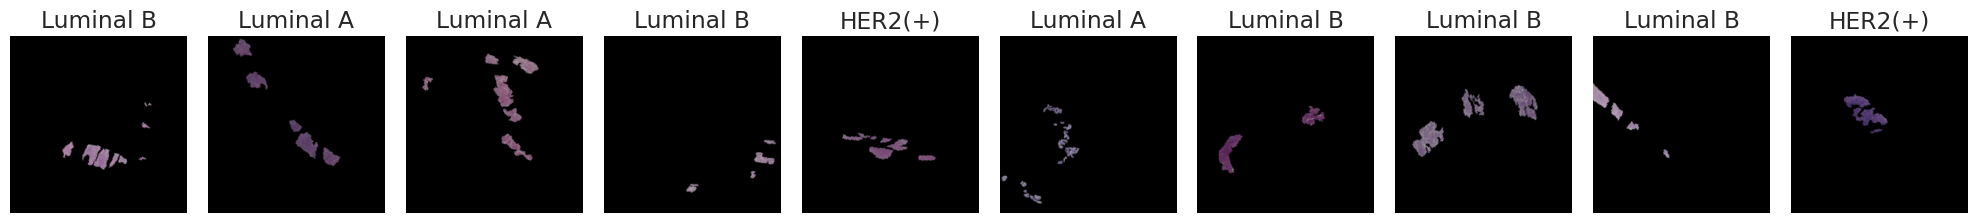

In [14]:
# Display a sample of images from the training dataset
num_img = 10

# Reverse the class_map to get labels for plotting
idx_to_class = {v: k for k, v in train_ds.class_map.items()}
unique_labels = list(idx_to_class.values())

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Get random indices for images from the training dataset
random_indices = random.sample(range(len(train_ds)), num_img)

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    image, label_idx = train_ds[idx]
    # Convert image tensor to numpy and permute dimensions for matplotlib (C, H, W -> H, W, C)
    image_np = image.permute(1, 2, 0).numpy()

    # Denormalize image for correct display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = std * image_np + mean
    image_np = np.clip(image_np, 0, 1) # Clip values to [0, 1] range

    ax.imshow(image_np)
    ax.set_title(f'{idx_to_class[label_idx]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
plt.show()


In [ ]:
# Inspect the target
print('Counting occurrences of target classes:')
print(train_df['label'].value_counts())


Counting occurrences of target classes:
label
Luminal B          341
Luminal A          266
HER2(+)            253
Triple negative    115
Name: count, dtype: int64


## 🧮 **Network Parameters**

In [ ]:
# Number of training epochs
LEARNING_RATE = 1e-4
EPOCHS = 1000
PATIENCE = 10

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rare:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)

Epochs: 1000
Batch Size: 32
Learning Rare: 0.0001
Dropout Rate: 0.2
L1 Penalty: 0
L2 Penalty: 0


## 👁️ **Simple CNN**

In [ ]:
# CNN Architecture parameters
# Number of convolutional blocks
NUM_BLOCKS = 3

# Number of conv layers per block
CONVS_PER_BLOCK = 2

# Use strided convolutions instead of pooling
USE_STRIDE = False

# Stride value when USE_STRIDE is True
STRIDE_VALUE = 2

# Padding size
PADDING_SIZE = 1

# Pooling size when USE_STRIDE is False
POOL_SIZE = 2

# Number of channels in first block
INITIAL_CHANNELS = 32

# Channel multiplication factor between blocks
CHANNEL_MULTIPLIER = 2

print("Num Blocks:", NUM_BLOCKS)
print("Convs per Block:", CONVS_PER_BLOCK)
print("Use Stride:", USE_STRIDE)
print("Stride Value:", STRIDE_VALUE)
print("Padding Size:", PADDING_SIZE)
print("Pool Size:", POOL_SIZE)
print("Initial Channels:", INITIAL_CHANNELS)
print("Channel Multiplier:", CHANNEL_MULTIPLIER)

Num Blocks: 3
Convs per Block: 2
Use Stride: False
Stride Value: 2
Padding Size: 1
Pool Size: 2
Initial Channels: 32
Channel Multiplier: 2


In [ ]:
# Single convolutional block with multiple conv layers, ReLU and pooling/stride
class VanillaCNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs=1, use_stride=False, stride_value=2, padding_size=1, pool_size=2):
        super().__init__()

        layers = []

        # First convolution: in_channels -> out_channels
        if num_convs == 1:
            # Single conv: apply stride here if use_stride is True
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))
        else:
            # Multiple convs: first one always has stride=1
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1))

            # Intermediate convolutions (all with stride=1)
            for i in range(1, num_convs - 1):
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1))

            # Last convolution: apply stride here if use_stride is True
            stride = stride_value if use_stride else 1
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))

        # ReLU activation
        layers.append(nn.ReLU())

        # Pooling only if not using stride for spatial reduction
        if not use_stride:
            layers.append(nn.MaxPool2d(kernel_size=pool_size, stride=pool_size))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# Convolutional Neural Network architecture for CIFAR10 classification
class CNN(nn.Module):
    def __init__(self, input_shape=(3,32,32), num_classes=10, dropout_rate=DROPOUT_RATE,
                 num_blocks=NUM_BLOCKS, convs_per_block=CONVS_PER_BLOCK,
                 use_stride=USE_STRIDE, stride_value=STRIDE_VALUE, padding_size=PADDING_SIZE, pool_size=POOL_SIZE,
                 initial_channels=INITIAL_CHANNELS, channel_multiplier=CHANNEL_MULTIPLIER):
        super().__init__()

        # Build convolutional blocks
        blocks = []
        in_channels = input_shape[0]
        out_channels = initial_channels

        for i in range(num_blocks):
            blocks.append(VanillaCNNBlock(
                in_channels=in_channels,
                out_channels=out_channels,
                num_convs=convs_per_block,
                use_stride=use_stride,
                stride_value=stride_value,
                padding_size=padding_size,
                pool_size=pool_size
            ))

            # Prepare for next block: increase channels
            in_channels = out_channels
            out_channels = out_channels * channel_multiplier

        self.features = nn.Sequential(*blocks)

        # Calculate flattened size after all blocks using a dummy forward pass
        # This approach is robust and works with any configuration of padding, stride, and pooling
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self.features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head: flatten features and apply dropout before final layer
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    # Forward pass through the network
    def forward(self, x):
        x = self.features(x)
        x = self.classifier_head(x)
        return x

In [ ]:
# Define input shape and number of classes
input_shape = (3, IMG_SIZE, IMG_SIZE)  # 3 channels (RGB), IMG_SIZE x IMG_SIZE
num_classes = len(train_ds.class_map) # Get number of classes from the dataset

# Instantiate CNN model and move to computing device (CPU/GPU)
cnn_model = CNN(
    input_shape,
    num_classes,
    num_blocks=NUM_BLOCKS,
    convs_per_block=CONVS_PER_BLOCK,
    use_stride=USE_STRIDE,
    stride_value=STRIDE_VALUE,
    padding_size=PADDING_SIZE,
    pool_size=POOL_SIZE,
    initial_channels=INITIAL_CHANNELS,
    channel_multiplier=CHANNEL_MULTIPLIER
    ).to(device)

# Display model architecture summary
summary(cnn_model, input_size=input_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
            Conv2d-2         [-1, 32, 224, 224]           9,248
              ReLU-3         [-1, 32, 224, 224]               0
         MaxPool2d-4         [-1, 32, 112, 112]               0
   VanillaCNNBlock-5         [-1, 32, 112, 112]               0
            Conv2d-6         [-1, 64, 112, 112]          18,496
            Conv2d-7         [-1, 64, 112, 112]          36,928
              ReLU-8         [-1, 64, 112, 112]               0
         MaxPool2d-9           [-1, 64, 56, 56]               0
  VanillaCNNBlock-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 128, 56, 56]          73,856
           Conv2d-12          [-1, 128, 56, 56]         147,584
             ReLU-13          [-1, 128, 56, 56]               0
        MaxPool2d-14          [-1, 128,

In [ ]:
# Set up TensorBoard logging and save model architecture
experiment_name = "cnn"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)
writer.add_graph(cnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

## 🧠 **Model Training**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [ ]:
%%time
# Train model and track training history
cnn_model, training_history = fit(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="cnn",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = cnn_model
    best_performance = training_history['val_f1'][-1]

Training 1000 epochs...
Epoch   1/1000 | Train: Loss=1.3472, F1 Score=0.2509 | Val: Loss=1.3267, F1 Score=0.1838
Epoch   2/1000 | Train: Loss=1.3311, F1 Score=0.1813 | Val: Loss=1.3327, F1 Score=0.1838
Epoch   3/1000 | Train: Loss=1.3303, F1 Score=0.1813 | Val: Loss=1.3242, F1 Score=0.1838
Epoch   4/1000 | Train: Loss=1.3310, F1 Score=0.1813 | Val: Loss=1.3254, F1 Score=0.1838
Epoch   5/1000 | Train: Loss=1.3272, F1 Score=0.1852 | Val: Loss=1.3338, F1 Score=0.1964
Epoch   6/1000 | Train: Loss=1.3265, F1 Score=0.1826 | Val: Loss=1.3275, F1 Score=0.1846
Epoch   7/1000 | Train: Loss=1.3193, F1 Score=0.2167 | Val: Loss=1.3375, F1 Score=0.2139
Epoch   8/1000 | Train: Loss=1.3281, F1 Score=0.1972 | Val: Loss=1.3234, F1 Score=0.1838
Epoch   9/1000 | Train: Loss=1.3261, F1 Score=0.1809 | Val: Loss=1.3247, F1 Score=0.1838
Epoch  10/1000 | Train: Loss=1.3233, F1 Score=0.1919 | Val: Loss=1.3339, F1 Score=0.1846
Epoch  11/1000 | Train: Loss=1.3217, F1 Score=0.1949 | Val: Loss=1.3426, F1 Score=0.19

In [ ]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [ ]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = cnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

In [ ]:
# @title Activation visualisation
def get_activation(name):
    """Creates a hook function to capture and store layer outputs."""
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook


def find_last_conv_layer(model):
    """
    Identifies the final Conv2D layer in the model architecture.
    """
    last_conv_name = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv_name = name

    if last_conv_name is None:
        raise ValueError("No Conv2D layer found in the model.")
    return last_conv_name


def visualize(model, X, y, unique_labels, num_images=50, display_activations=True, display_all_conv_layers=False):
    """
    Visualises model predictions and internal activations for a random test image.
    Uses PyTorch hooks to extract intermediate layer outputs.

    Args:
        display_all_conv_layers: If True, shows all conv layers. If False, shows only last conv of each block.
    """

    # --- 1. Select Image and Prepare Tensor ---

    # Randomly select an image from the dataset
    image_idx = np.random.randint(0, num_images)
    img_np = X[image_idx]
    label_np = y[image_idx]

    # Convert NumPy array to PyTorch tensor with correct dimensions
    # Transform from (H, W, C) to (N, C, H, W) format
    img_tensor = torch.from_numpy(img_np)
    img_tensor = img_tensor.permute(2, 0, 1)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # --- 2. Register Hooks and Make Prediction ---

    # Clear previous activations
    activations.clear()

    # Attach forward hooks to convolutional layers
    hooks = []
    conv_names = []

    # Iterate through all blocks in the features Sequential
    for block_idx, block in enumerate(model.features):
        # Find all Conv2d layers in this block
        conv_layers_in_block = []
        for layer_idx, layer in enumerate(block.block):
            if isinstance(layer, nn.Conv2d):
                conv_layers_in_block.append((layer_idx, layer))

        # Register hooks based on display_all_conv_layers flag
        if display_all_conv_layers:
            # Register hook for every Conv2d layer
            for layer_idx, conv_layer in conv_layers_in_block:
                hook_name = f'block{block_idx}_conv{layer_idx}'
                conv_names.append(hook_name)
                hooks.append(conv_layer.register_forward_hook(get_activation(hook_name)))
        else:
            # Register hook only for the last Conv2d layer in this block
            if conv_layers_in_block:
                layer_idx, conv_layer = conv_layers_in_block[-1]
                hook_name = f'block{block_idx}_conv{layer_idx}'
                conv_names.append(hook_name)
                hooks.append(conv_layer.register_forward_hook(get_activation(hook_name)))

    # Generate prediction with gradient tracking disabled
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probabilities = torch.softmax(logits, dim=1)

    # Remove hooks after forward pass
    for hook in hooks:
        hook.remove()

    # Extract predicted class and confidence
    predictions = probabilities.cpu().numpy()
    class_int = np.argmax(predictions[0])
    class_str = unique_labels[class_int]

    # Extract true class (handle both one-hot encoded and integer labels)
    if label_np.ndim > 0 and len(label_np) > 1:
        # One-hot encoded
        true_class_int = np.argmax(label_np)
    else:
        # Already an integer index
        true_class_int = int(label_np)
    true_class_str = unique_labels[true_class_int]

    # --- 3. Plot Image and Prediction Bar ---

    # Create figure with custom layout
    fig = plt.figure(constrained_layout=True, figsize=(16, 4))
    gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.5, 1.5], wspace=0)

    # Display original image with true label
    ax1 = fig.add_subplot(gs[0])
    ax1.set_title(f"True class: {true_class_str}", loc='left')
    if img_np.shape[-1] == 1:
        ax1.imshow(np.squeeze(img_np), cmap='bone', vmin=0., vmax=1.)
    else:
        ax1.imshow(np.squeeze(img_np), vmin=0., vmax=1.)
    ax1.axis('off')

    # Display class probability distribution
    ax2 = fig.add_subplot(gs[1])
    ax2.barh(unique_labels, np.squeeze(predictions, axis=0), color=plt.get_cmap('tab10').colors)
    ax2.set_title(f"Predicted class: {class_str} (Confidence: {max(np.squeeze(predictions[0])):.2f})", loc='left')
    ax2.grid(alpha=0.3)
    ax2.set_xlim(0.0, 1.0)
    plt.show()

    # --- 4. Plot Activations ---

    if display_activations:
        # Visualise activations for each registered layer
        for conv_name in conv_names:
            # Retrieve stored activations from hooks
            layer_activations = activations[conv_name]

            # Get number of channels
            num_channels = layer_activations.shape[1]

            # Display up to 16 feature maps per layer
            num_display = min(16, num_channels)

            # Calculate grid layout
            if num_display <= 8:
                rows, cols = 1, num_display
                figsize = (18, 3)
            else:
                rows, cols = 2, 8
                figsize = (18, 5)

            # Create subplot grid
            fig, axes = plt.subplots(rows, cols, figsize=figsize)

            # Flatten axes array for easier indexing
            if num_display > 1:
                axes = axes.flatten() if rows > 1 or cols > 1 else [axes]
            else:
                axes = [axes]

            # Plot each activation map
            for i in range(num_display):
                ax = axes[i]
                activation_map = layer_activations[0, i].cpu().numpy()
                ax.imshow(activation_map, cmap='bone', vmin=np.min(activation_map), vmax=np.max(activation_map))
                ax.axis('off')
                if i == 0:
                    ax.set_title(f'{conv_name} activations', loc='left')

            # Hide unused subplots
            for i in range(num_display, len(axes)):
                axes[i].axis('off')

            plt.tight_layout()
            plt.show()

## 🛠️ **Transfer Learning**

In [ ]:
class EfficientNetB0TransferLearning(nn.Module):
    """EfficientNet-B0 with ImageNet pretrained weights."""

    def __init__(self, num_classes, dropout_rate=0.3, freeze_backbone=True):
        super().__init__()

        # Load weights pretrained on ImageNet
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
        )

        # Freeze the backbone layers (features)
        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False

        # Replace classifier (Always trainable)
        in_features = self.backbone.classifier[-1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

In [ ]:
# Create transfer learning model
tl_model = EfficientNetB0TransferLearning(num_classes, DROPOUT_RATE, freeze_backbone=True).to(device)

# Display model summary
summary(tl_model, input_size=input_shape)

In [ ]:
# Setup training
experiment_name = "transfer_learning"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
optimizer = torch.optim.Adam(tl_model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
%%time
# Train with transfer learning
tl_model, tl_history = fit(
    model=tl_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=5,
    experiment_name=experiment_name,
    patience=PATIENCE
)

final_val_acc = round(max(tl_history['val_acc']) * 100, 2)
print(f'Final validation accuracy: {final_val_acc}%')

## 🛠️ **Fine-Tuning**

In [ ]:
# Load the transfer learning model
ft_model = EfficientNetB0TransferLearning(num_classes, DROPOUT_RATE, freeze_backbone=False).to(device)
ft_model.load_state_dict(torch.load("models/transfer_learning_model.pt"))

# Unfreeze the last N layers of the backbone
N_LAYERS_TO_UNFREEZE = 20

# Strategy: Freeze everything first, then unfreeze the last few blocks
for param in ft_model.parameters():
    param.requires_grad = False

# The classifier is always trainable
for param in ft_model.backbone.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last 2 blocks of the feature extractor (EfficientNet-B0 has 9 blocks usually)
# Adjust slice index [-2:] to unfreeze more or fewer layers
for block in ft_model.backbone.features[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# Check trainable parameters
trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

In [ ]:
# Setup Training (Lower learning rate for Fine-Tuning)
experiment_name = "fine_tuning"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4) # 10x smaller LR
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [ ]:
%%time
# Fine-tune the model
ft_model, ft_history = fit(
    model=ft_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=5,
    experiment_name=experiment_name,
    patience=PATIENCE
)

final_val_acc = round(max(ft_history['val_acc']) * 100, 2)
print(f'Final validation accuracy: {final_val_acc}%')

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(ft_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(ft_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(ft_history['train_acc'], label='Training Accuracy', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(ft_history['val_acc'], label='Validation Accuracy', alpha=0.9, color='#ff7f0e')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [ ]:
# Copy TensorBoard logs to accessible location for Colab
!rsync -a $current_dir"/"$logs_dir/ "/content/"$logs_dir/

# Launch TensorBoard interface
%tensorboard --logdir "/content/"$logs_dir

## 🕹️ Use the Model - Make Inference

In [ ]:
# Dictionary to store layer activations via forward hooks
activations = {}

# Visualise model predictions and internal representations
# Set display_all_conv_layers=True to show all conv layers, False for only last conv of each block
visualize(best_model, X_test, y_test, unique_labels, display_activations=True, display_all_conv_layers=False)

In [ ]:
# Collect predictions and ground truth labels
test_preds, test_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        test_preds.append(preds)
        test_targets.append(yb.numpy())

# Combine all batches into single arrays
test_preds = np.concatenate(test_preds)
test_targets = np.concatenate(test_targets)

In [ ]:
# Calculate overall test accuracy
test_acc = accuracy_score(test_targets, test_preds)
test_prec = precision_score(test_targets, test_preds, average='weighted')
test_rec = recall_score(test_targets, test_preds, average='weighted')
test_f1 = f1_score(test_targets, test_preds, average='weighted')
print(f"Accuracy over the test set: {test_acc:.4f}")
print(f"Precision over the test set: {test_prec:.4f}")
print(f"Recall over the test set: {test_rec:.4f}")
print(f"F1 score over the test set: {test_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(test_targets, test_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()